# Week 5 — Day 1: Unsupervised Learning & K-Means Clustering

**Dataset:** Mall Customers  
**Task:** Unsupervised clustering — discover natural customer segments

---

## Objective

Transition from supervised to unsupervised learning. Apply K-Means clustering to find natural groupings in customer data, choose the right number of clusters using the elbow method and silhouette score, and interpret what each cluster represents.

## Lesson Content

### 1.1 — Supervised vs. Unsupervised Learning

In supervised learning (Weeks 3–4), every training example had a known correct answer — the target y. Unsupervised learning works on data with no labels at all: there is no y. Instead of predicting a known answer, the goal is to discover hidden structure the data contains on its own: natural groupings, underlying dimensions, or unusual points.

| | Supervised | Unsupervised |
|---|---|---|
| Data | Has labels (X and y) | No labels (X only) |
| Goal | Predict the known target | Discover hidden structure |
| Examples | Regression, classification | Clustering, dimensionality reduction, anomaly detection |
| Evaluation | Compare prediction to true label | No ground truth — uses internal metrics and judgment |

*Applied in Hands-On: all steps.*

---

### 1.2 — What Clustering Does

Clustering groups data points so that points in the same group are similar to each other and different from points in other groups. It answers questions like "what natural customer segments exist?" without anyone having pre-defined those segments. Because there are no labels, the algorithm finds structure purely from the shape of the data.

*Applied in Hands-On: Steps 2–5.*

---

### 1.3 — K-Means, Step by Step

K-Means partitions data into a chosen number of clusters (k) by repeating two steps until stable:

1. Place k cluster centers ("centroids"), initially at random.
2. Assign each point to its nearest centroid.
3. Move each centroid to the mean position of the points assigned to it.
4. Repeat steps 2–3 until the centroids stop moving.

```python
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = km.fit_predict(X)
print(km.cluster_centers_)   # the final centroid positions
```

Always scale features before clustering. K-Means uses distance, so an unscaled large-range feature (like income) would dominate a small-range one (like age).

*Applied in Hands-On: Steps 1, 4.*

---

### 1.4 — Choosing k: the Elbow Method

K-Means needs you to choose k in advance, but the right k is rarely obvious. The elbow method runs K-Means for a range of k values and plots the inertia (total within-cluster distance) against k. Inertia always falls as k rises, but the rate of improvement drops sharply at the right k — creating an "elbow" in the plot. That elbow is the recommended k.

```python
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_)

plt.plot(range(1, 11), inertias, marker="o")
```

*Applied in Hands-On: Step 2.*

---

### 1.5 — Choosing k: the Silhouette Score

The silhouette score is a more quantitative check: it measures how well each point sits inside its own cluster versus the nearest other cluster, on a scale from -1 to +1. A higher average silhouette score means better-defined clusters. Comparing the score across candidate k values gives a data-driven choice to confirm the elbow.

```python
from sklearn.metrics import silhouette_score

score = silhouette_score(X, labels)
```
*Applied in Hands-On: Step 3.*



### Comparing the Two Methods (Elbow Method vs. Silhouette Score)

| | Elbow Method | Silhouette Score |
|---|---|---|
| What it measures | Rate of inertia decrease across k values | How well each point fits its own cluster vs. the nearest other |
| Output | A plot — you pick the bend visually | A number between -1 and +1 — higher is better |
| Best used for | Narrowing down candidate k values | Confirming which candidate k is better |
| Limitation | Subjective — the elbow is not always obvious | Can favor compact clusters even when the elbow disagrees |

Use both together: the elbow shortlists, the silhouette score decides.


## Hands-On Lab: K-Means Clustering

In this lab, the Mall Customers dataset is loaded, scaled, and clustered with K-Means. The elbow method and silhouette score are used together to pick the best k. The final clusters are visualized on a 2D scatter plot and interpreted in business terms.

### Imports

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### Step 1: Load and Scale the Dataset

Only numeric features are used for clustering. `CustomerID` is an identifier with no signal; `Gender` is categorical and excluded to keep the feature space numeric and distance-meaningful. The remaining three features — Age, Annual Income, and Spending Score — are scaled with `StandardScaler` so no single feature dominates the distance calculation.

In [58]:
df = pd.read_csv("Mall_Customers.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [59]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [60]:
# Select numeric features only
X = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].copy()

# Scale so all features contribute equally to distance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled features shape:", X_scaled.shape)

Scaled features shape: (200, 3)


The dataset contains 200 customers. After dropping the identifier and categorical gender column, three numeric features remain. Scaling brings all three onto the same range before distance-based clustering.

### Step 2: Elbow Method — Finding the Optimal k

K-Means is run for k from 1 to 10. Inertia (total squared distance from each point to its cluster centroid) is recorded for each k and plotted. The point where the rate of decrease levels off — the "elbow" — indicates the best k.

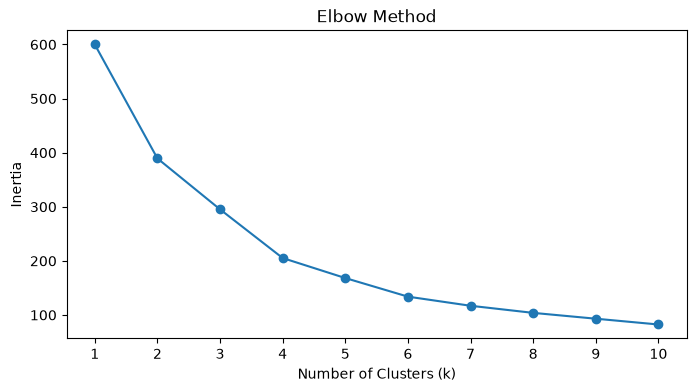

In [61]:
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(range(1, 11))
plt.show()

The elbow plot gives us a strong visual clue, but the bend is not perfectly sharp. So how can we confirm whether k = 5 or k = 6 creates better-separated clusters

### Step 3: Silhouette Score — Confirming the Best k

The silhouette score is computed for the top two candidate k values identified from the elbow plot. The higher score confirms the better k.

In [62]:
# Replace with the two candidate k=[5,6] values from the elbow plot
candidates = [5,6]

for k in candidates:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}  silhouette score: {score:.4f}")

k=5  silhouette score: 0.4166
k=6  silhouette score: 0.4284


The elbow plot suggested that k = 6 was the strongest candidate.

The silhouette score confirms this result:
k=5 -> 0.4166
k=6 -> 0.4284

Since k = 6 has the higher silhouette score, I will use 6 clusters for the final K-Means model.

### Step 4: Fit Final K-Means and Visualize Clusters

The final K-Means model is fit with the chosen k. Clusters are visualized on a 2D scatter plot using Annual Income vs. Spending Score — the two features that best reveal customer segments. Centroids are marked with an X.

In [63]:
k_final = 6

km_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df["Cluster"] = km_final.fit_predict(X_scaled)

centroids_original = scaler.inverse_transform(km_final.cluster_centers_)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=["Age", "Annual Income (k$)", "Spending Score (1-100)"]
)
print(centroids_df.round(1))

df[["Age", "Annual Income (k$)", "Spending Score (1-100)", "Cluster"]].head()

    Age  Annual Income (k$)  Spending Score (1-100)
0  56.3                54.3                    49.1
1  26.8                57.1                    48.1
2  41.9                88.9                    17.0
3  32.7                86.5                    82.1
4  25.0                25.3                    77.6
5  45.5                26.3                    19.4


,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,19,15,39,4
1,21,15,81,4
2,20,16,6,5
3,23,16,77,4
4,31,17,40,5


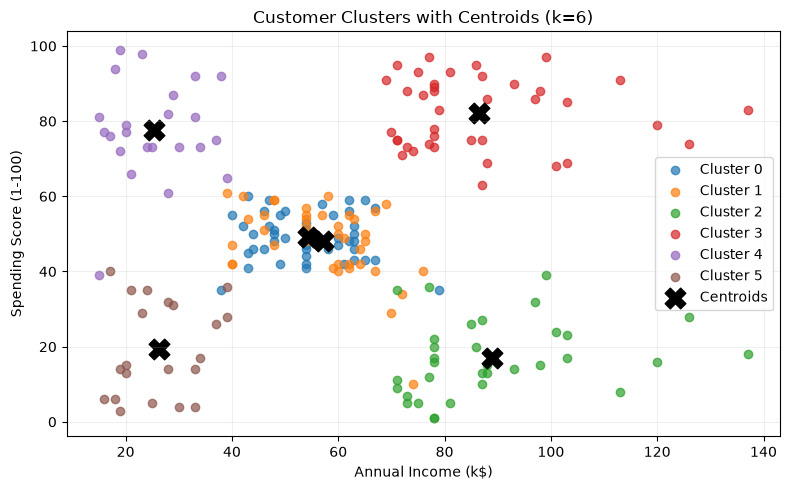

In [64]:
fig, ax = plt.subplots(figsize=(8, 5))

for cluster in sorted(df["Cluster"].unique()):
    group = df[df["Cluster"] == cluster]
    ax.scatter(
        group["Annual Income (k$)"],
        group["Spending Score (1-100)"],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

ax.scatter(
    centroids_original[:, 1],
    centroids_original[:, 2],
    marker="X",
    s=220,
    c="black",
    edgecolors="black",
    label="Centroids"
)

ax.set_xlabel("Annual Income (k$)")
ax.set_ylabel("Spending Score (1-100)")
ax.set_title(f"Customer Clusters with Centroids (k={k_final})")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Step 5: Cluster Interpretation


**Cluster 0 & 1** — Medium income, medium spending. The average customer. Both groups overlap in this 2D view; Age separates them in the full feature space.

**Cluster 2** — High income, low spending. Under-engaged customers with purchasing power. The biggest missed opportunity.

**Cluster 3** — High income, high spending. The most valuable segment — priority for loyalty programs.

**Cluster 4** — Low income, high spending. High engagement but limited capacity.

**Cluster 5** — Low income, low spending. Lowest commercial priority.

## Final Summary

The elbow method identified k=5 and k=6 as candidates. The silhouette score confirmed k=6 (0.4284 vs 0.4166), producing better-separated clusters.

The six clusters segment customers along two primary axes — income and spending score — with Age providing additional separation between overlapping middle groups. The two most actionable segments are Cluster 3 (high income, high spending — retain and reward) and Cluster 2 (high income, low spending — re-engage). Cluster 0 and Cluster 1 form the broad middle market with moderate priority.